# Model pipeline - Classification  

This notebook fits and evaluates several classification models for predicting the presence or absence of a biodiversity anomaly based on weather features  

Note: Time series data - cannot use random train-test split (that would leak future information)

---
### Load packages and data

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, recall_score
from xgboost import XGBClassifier

from sklearn import set_config
set_config(transform_output='pandas')

In [2]:
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

Select only necessary columns - use sensitive biodiversity anomaly threshold

In [3]:
df = full_df[['state', 'year_offset', 'month_sin', 'month_cos',
              'n_hot_days', 'n_hot_days_lag1', 'n_hot_days_roll3', 
              'heavy_rain_days', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
              'temp_anom_z', 'temp_anom_z_lag1', 'temp_anom_z_roll3',
              'precip_anom_z', 'precip_anom_z_lag1', 'precip_anom_z_roll3',
              'drought_index', 'drought_index_lag1', 'drought_index_roll3',
              'log_n_obs', 'biodiversity_anomaly_sensitive']].copy()        

In [4]:
df.sample(10)

,state,year_offset,month_sin,month_cos,n_hot_days,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days,heavy_rain_days_lag1,heavy_rain_days_roll3,...,temp_anom_z_lag1,temp_anom_z_roll3,precip_anom_z,precip_anom_z_lag1,precip_anom_z_roll3,drought_index,drought_index_lag1,drought_index_roll3,log_n_obs,biodiversity_anomaly_sensitive
58,Baden-Württemberg,4,-5.000000e-01,8.660254e-01,0,0.0,0.000000,1,4.0,2.666667,...,-0.576801,-0.931386,-0.635647,1.976838,0.754347,-0.297487,-2.553639,-1.685733,3.128399,0
2638,Rheinland-Pfalz,9,-5.000000e-01,8.660254e-01,0,0.0,0.333333,2,2.0,1.333333,...,0.655852,0.018507,0.421590,1.057225,0.495272,-1.273807,-0.401373,-0.476765,3.544812,1
787,Brandenburg,2,-8.660254e-01,-5.000000e-01,0,9.0,3.000000,1,1.0,0.666667,...,2.586273,0.744899,0.374033,-0.921026,-0.618755,-1.669251,3.507298,1.363654,2.606381,1
2055,Niedersachsen,3,8.660254e-01,-5.000000e-01,0,0.0,0.000000,0,2.0,1.666667,...,1.018889,1.075789,-1.764063,0.545217,0.908243,3.073798,0.473673,0.167545,2.809560,0
2594,Rheinland-Pfalz,6,1.000000e+00,6.123234e-17,0,0.0,0.000000,0,1.0,1.333333,...,-0.975763,-1.259157,-0.565265,0.098709,-0.124006,0.155280,-1.074472,-1.135151,3.446537,1
1828,Mecklenburg-Vorpommern,5,5.000000e-01,-8.660254e-01,0,0.0,0.000000,1,0.0,0.666667,...,1.682345,0.375137,0.235900,-1.617645,-0.471460,-0.324950,3.299990,0.846597,3.664360,0
1644,Hessen,11,5.000000e-01,8.660254e-01,0,0.0,0.000000,1,2.0,2.000000,...,0.180399,0.776204,0.150939,0.078222,-0.152929,0.103850,0.102178,0.929134,4.382071,1
1697,Hessen,15,1.224647e-16,-1.000000e+00,3,0.0,0.000000,2,5.0,3.000000,...,-1.353590,-0.023652,-0.166646,1.194478,0.682412,2.184288,-2.548068,-0.706063,4.193319,0
903,Brandenburg,12,8.660254e-01,-5.000000e-01,0,0.0,0.000000,1,1.0,1.000000,...,-0.201159,0.014022,0.516824,-0.614079,-0.194768,-1.053498,0.412919,0.208790,3.587037,1
2886,Saarland,9,-5.000000e-01,-8.660254e-01,3,2.0,0.666667,1,4.0,3.333333,...,-1.272247,-1.174567,-0.566109,0.734134,1.261533,1.153508,-2.006381,-2.436100,2.311754,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           4032 non-null   object 
 1   year_offset                     4032 non-null   int32  
 2   month_sin                       4032 non-null   float64
 3   month_cos                       4032 non-null   float64
 4   n_hot_days                      4032 non-null   int64  
 5   n_hot_days_lag1                 4032 non-null   float64
 6   n_hot_days_roll3                4032 non-null   float64
 7   heavy_rain_days                 4032 non-null   int64  
 8   heavy_rain_days_lag1            4032 non-null   float64
 9   heavy_rain_days_roll3           4032 non-null   float64
 10  temp_anom_z                     4032 non-null   float32
 11  temp_anom_z_lag1                4032 non-null   float32
 12  temp_anom_z_roll3               40

---
### Define X and y and create train-test splits  

Note that due to time-series data, random train-test split is not appropriate. Instead, split data based on year so that there is no leakage from future data in training.  

Use rolling/walk-forward/expanding-window validation within training set for more robust validation.

In [6]:
df.value_counts('year_offset')

year_offset
0     192
1     192
2     192
3     192
4     192
5     192
6     192
7     192
8     192
9     192
10    192
11    192
12    192
13    192
14    192
15    192
16    192
17    192
18    192
19    192
20    192
Name: count, dtype: int64

In [7]:
train_val = df.loc[df['year_offset']<17]
test = df.loc[df['year_offset']>=17]

Create X_test and y_test

In [8]:
X_test = test.copy()
y_test = X_test.pop('biodiversity_anomaly_sensitive')

For X_train and y_train when using walk-forward validation with expanding window, need to define these within a loop and fit the pipeline (defined below) to each iteration.  

---
### Baseline model

Biodiversity anomalies are rare, so predict all 0s for baseline model

In [9]:
X_trainval = train_val.copy()
y_trainval = X_trainval.pop('biodiversity_anomaly_sensitive')

In [10]:
# Dummy model
dummy_model = DummyClassifier()
dummy_model.fit(X_trainval, y_trainval)
dummy_train_pred = dummy_model.predict(X_trainval)

In [11]:
#calculate dummy model training set accuracy
train_accuracy = accuracy_score(y_true = y_trainval,
                                y_pred = dummy_train_pred)

round(train_accuracy, 2)

0.58

In [12]:
#calculate dummy model training set f1 score
# use macro f1 as it is more important to detect the minority class (present) than to avoid false positives
train_f1 = f1_score(y_true = y_trainval,
                    y_pred = dummy_train_pred,
                    average = 'macro')

round(train_f1, 2)

0.37

In [13]:
#calculate dummy model training set recall score
# use macro f1 as it is more important to detect the minority class (present) than to avoid false positives
train_recall = recall_score(y_true = y_trainval,
                    y_pred = dummy_train_pred)

round(train_f1, 2)

0.37

Aiming for accuracy > 58% and F1 and recall > 0.37 in trained models

---
### Create pipeline

Define branches for numeric and categorical preprocessing for each model in model selection step (below)

Distance-based models (e.g. KNN) needs scaled features but Tree-based models don't

In [14]:
cat_features = ['state']
cyc_features = ['month_sin', 'month_cos']
num_features = [col for col in X_test.columns if (col not in (cat_features + cyc_features))]

In [15]:
# Create pipelines for numeric (non-cyclical) variables
# (cyclical vars are already in the range -1 to 1, no need to scale)
num_pipe_scale = Pipeline([
    ('scaler', MinMaxScaler())
])

# Build categorical pipeline (with one-hot-encoding for state)
oh_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Create preprocessors for models that need scaling (distance-based) and those that don't (trees)

In [16]:
preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features),
        ('cyc', 'passthrough', cyc_features)
    ]
)

preprocessor_noscale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Build full pipeline for each model:  

First, tree-based models (no scaling needed)

In [17]:
# XGBoost
full_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('model', XGBClassifier())
])


---
Model selection and fine tuning

define model & grid

In [18]:
models = {
    'XGBoost': {
        'pipeline': full_pipeline_xgb,
        'param_grid': {
            'model__n_estimators': [500, 1000],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__subsample': [0.7, 1.0],
            'model__colsample_bytree': [0.7, 1.0],
            'model__scale_pos_weight': [1, 4, 5]  # for imbalance
        }
    }
}

---
Use manual time-aware train-val split

In [19]:
# Helper function for expanding splits
def get_expanding_splits(years, min_train_years=5):
    splits = []
    
    for i in range(min_train_years, len(years)):
        train_years = years[:i]
        val_year = years[i]
        splits.append((train_years, val_year))
    
    return splits

Let's try using Bayesian optimisation (Optuna), which intelligently searches the space instead of trying everything, with early stopping.  

Note: Early stopping only works for some models (in this case, only XGBoost, not KNN or RF)  
Don't use early stopping with pipelines

In [20]:
# Define function for Bayesian searching with Optuna (scoring using ROC-AUC curve (proba threshold independent))

import optuna
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import roc_auc_score

def optuna_rolling_search_auc(
    df,
    features,
    target,
    pipeline,
    param_space_fn,
    min_train_years=10,
    n_trials=50,
):
    """
    Rolling-year CV Optuna search using ROC AUC (threshold-independent).
    """

    # 1️⃣ Prepare rolling splits
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)

    def objective(trial):
        # 2️⃣ Sample hyperparameters
        params = param_space_fn(trial)

        fold_scores = []

        for train_years, val_year in splits:
            train = df[df['year_offset'].isin(train_years)]
            val   = df[df['year_offset'] == val_year]

            X_train, y_train = train[features], train[target]
            X_val, y_val     = val[features], val[target]

            # 3️⃣ Clone pipeline
            pipe = clone(pipeline)
            pipe.set_params(**params)

            # 4️⃣ Fit model
            pipe.fit(X_train, y_train)

            # 5️⃣ Predict probabilities
            y_proba = pipe.predict_proba(X_val)

            # Handle binary vs multiclass safely
            if y_proba.shape[1] == 2:
                y_proba = y_proba[:, 1]

            # 6️⃣ Compute ROC AUC for this fold
            try:
                auc = roc_auc_score(y_val, y_proba)
            except ValueError:
                # Happens if only one class present in y_val
                continue

            fold_scores.append(auc)

        # 7️⃣ Aggregate across folds
        if len(fold_scores) == 0:
            return 0.5  # neutral fallback

        return np.mean(fold_scores)

    # 8️⃣ Run Optuna
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    # 9️⃣ Collect results
    results = []
    for trial in study.trials:
        results.append({
            'params': trial.params,
            'mean_auc': trial.value,
        })

    results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)

    return study, results_df

c:\Users\Darach\miniconda3\envs\wildsignal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def xgb_param_space(trial):
    return {
        'model__n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'model__max_depth': trial.suggest_int('max_depth', 3, 8),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'model__subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'model__scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10), #higher for more attention to minority class (presence)
        'model__n_jobs': 1
    }

In [22]:
features = num_features + cyc_features + cat_features

study, results_df = optuna_rolling_search_auc(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb,
    param_space_fn=xgb_param_space,
    min_train_years=10,
    n_trials=50,
)


[I 2026-04-16 10:34:39,636] A new study created in memory with name: no-name-22538a77-3c02-4274-97b3-8befdb106a26
[I 2026-04-16 10:34:59,386] Trial 0 finished with value: 0.768977379186066 and parameters: {'n_estimators': 2844, 'max_depth': 8, 'learning_rate': 0.04903595568129876, 'subsample': 0.8485455881502026, 'colsample_bytree': 0.7123253503554323, 'scale_pos_weight': 1.944234961275683}. Best is trial 0 with value: 0.768977379186066.
[I 2026-04-16 10:35:19,816] Trial 1 finished with value: 0.7990856179800115 and parameters: {'n_estimators': 1899, 'max_depth': 6, 'learning_rate': 0.005409685562339718, 'subsample': 0.9650817315438629, 'colsample_bytree': 0.8849652816230814, 'scale_pos_weight': 4.434499430970773}. Best is trial 1 with value: 0.7990856179800115.
[I 2026-04-16 10:35:32,508] Trial 2 finished with value: 0.7928912018992289 and parameters: {'n_estimators': 919, 'max_depth': 8, 'learning_rate': 0.013023618864032848, 'subsample': 0.891536378264368, 'colsample_bytree': 0.7392

In [23]:
# # Sort by F1
# results_df.sort_values('mean_f1', ascending=False).head(10)

# Sort by ROC AUC
results_df.sort_values('mean_auc', ascending=False).head(10)

,params,mean_auc
40,"{'n_estimators': 1137, 'max_depth': 7, 'learni...",0.809772
44,"{'n_estimators': 1262, 'max_depth': 7, 'learni...",0.808891
42,"{'n_estimators': 795, 'max_depth': 7, 'learnin...",0.808202
31,"{'n_estimators': 1556, 'max_depth': 7, 'learni...",0.808057
23,"{'n_estimators': 1637, 'max_depth': 7, 'learni...",0.807905
34,"{'n_estimators': 1609, 'max_depth': 6, 'learni...",0.807669
24,"{'n_estimators': 960, 'max_depth': 8, 'learnin...",0.807633
22,"{'n_estimators': 1543, 'max_depth': 7, 'learni...",0.807496
21,"{'n_estimators': 1499, 'max_depth': 7, 'learni...",0.807224
20,"{'n_estimators': 1486, 'max_depth': 7, 'learni...",0.807106


In [24]:
# Best trial according to Optuna
best_trial = study.best_trial

print("Best AUC:", best_trial.value)
print("Best parameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best AUC: 0.809772159371241
Best parameters:
  n_estimators: 1137
  max_depth: 7
  learning_rate: 0.0035584236174960784
  subsample: 0.8565943381483427
  colsample_bytree: 0.9124727476669523
  scale_pos_weight: 2.266154347154741


Visualise results

C:\Users\Darach\AppData\Local\Temp\ipykernel_3220\2474202550.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study);


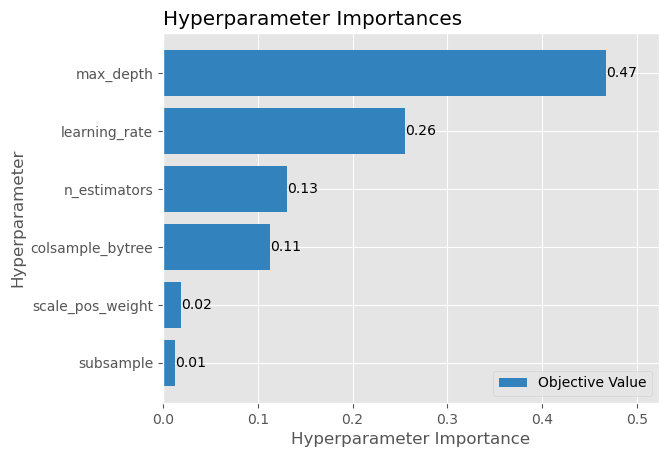

In [25]:
# Parameter importance
optuna.visualization.matplotlib.plot_param_importances(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_3220\2656397370.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study);


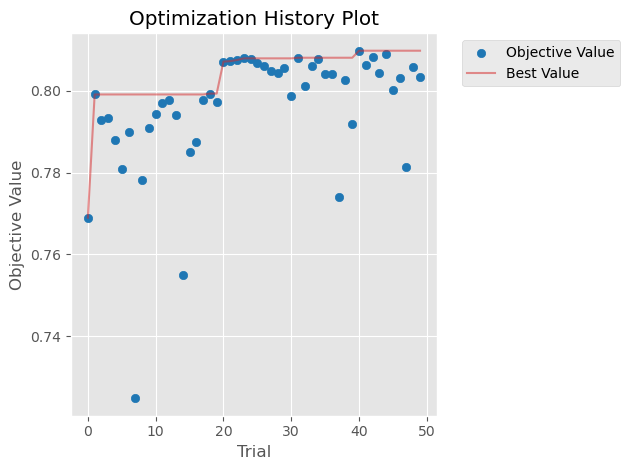

In [26]:
# Optimization history (how F1 improved over trials)
optuna.visualization.matplotlib.plot_optimization_history(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_3220\2949398106.py:2: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Axes: title={'center': 'Parallel Coordinate Plot'}>

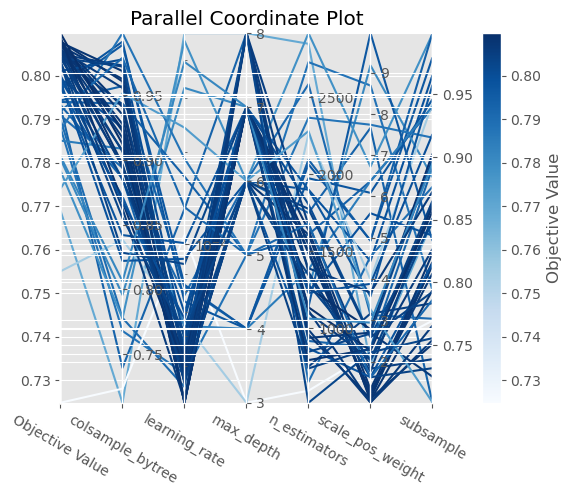

In [27]:
# Parallel coordinate plot (show trade-offs between params and F1)
optuna.visualization.matplotlib.plot_parallel_coordinate(study)

Now use best fitting parameters based on roc-auc to find best threshold value using precision-recall curves  
Set min recall quite high - 0.9 (we want to capture more biodiversity shocks at the risk of predicting more false positives)

In [28]:
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

def find_best_threshold_pr_curve(
    df,
    features,
    target,
    pipeline,
    best_params,
    min_train_years=10,
    min_recall=0.9,
    plot=True
):
    """
    Rolling validation + optimal threshold selection using PR curve geometry.
    """

    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)

    all_y_true = []
    all_y_proba = []

    # 1️⃣ Rolling predictions
    for train_years, val_year in splits:
        train = df[df['year_offset'].isin(train_years)]
        val   = df[df['year_offset'] == val_year]

        X_train, y_train = train[features], train[target]
        X_val, y_val     = val[features], val[target]

        pipe = clone(pipeline)
        pipe.set_params(**best_params)

        pipe.fit(X_train, y_train)

        y_proba = pipe.predict_proba(X_val)

        if y_proba.shape[1] == 2:
            y_proba = y_proba[:, 1]

        all_y_true.append(y_val.values)
        all_y_proba.append(y_proba)

    y_true = np.concatenate(all_y_true)
    y_proba = np.concatenate(all_y_proba)

    # 2️⃣ Precision–Recall curve (CORE IDEA)
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # thresholds has length N-1 (important detail)
    precision = precision[:-1]
    recall = recall[:-1]

    # 3️⃣ Apply constraint
    valid_idx = np.where(recall >= min_recall)[0]

    if len(valid_idx) > 0:
        # maximize precision under recall constraint
        best_idx = valid_idx[np.argmax(precision[valid_idx])]
    else:
        print("⚠️ No threshold meets recall constraint — fallback to max recall")
        best_idx = np.argmax(recall)

    best_threshold = thresholds[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]

    # 4️⃣ Final evaluation
    y_pred = (y_proba >= best_threshold).astype(int)

    final_precision = precision_score(y_true, y_pred, zero_division=0)
    final_recall = recall_score(y_true, y_pred)

    best = {
        "threshold": best_threshold,
        "precision": final_precision,
        "recall": final_recall
    }

    # 5️⃣ Plotting
    if plot:
        plt.figure()
        plt.plot(recall, precision)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve (Rolling Validation)")
        plt.grid()
        plt.show()

        plt.figure()
        plt.plot(thresholds, recall, label="Recall")
        plt.plot(thresholds, precision, label="Precision")
        plt.axvline(best_threshold, linestyle="--", label="Chosen threshold")
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.legend()
        plt.grid()
        plt.show()

    return best, {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds
    }

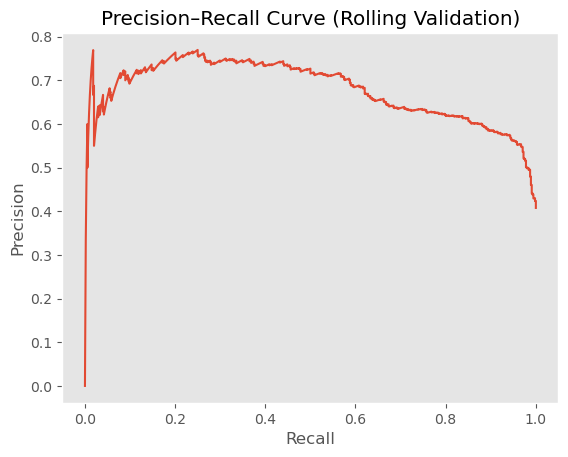

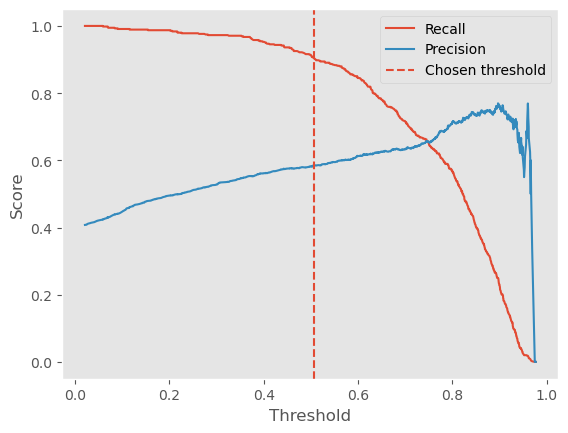

{'threshold': np.float32(0.5067265), 'precision': 0.5855962219598583, 'recall': 0.9051094890510949}


In [29]:
best_params_prefixed = {f"model__{k}": v for k, v in best_trial.params.items()}

best_threshold_info, threshold_results = find_best_threshold_pr_curve(
    df=train_val,
    features=features,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb,
    best_params=best_params_prefixed,
    min_recall=0.9,
    plot=True
)

print(best_threshold_info)

In [30]:
best_threshold_info['threshold']

np.float32(0.5067265)

Use best parameters for training on full training data

In [31]:
best_params = {f"model__{k}": v for k, v in best_trial.params.items()}
best_threshold = best_threshold_info['threshold']

# Set these in your pipeline
full_pipeline_xgb.set_params(**best_params)

# Fit the pipeline on full training data
full_pipeline_xgb.fit(X_trainval, y_trainval)

# Predict probabilities on test set
y_proba = full_pipeline_xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba > best_threshold).astype(int)

# Evaluate
from sklearn.metrics import f1_score, accuracy_score
print("F1 on test:", f1_score(y_test, y_pred, average='macro'))

F1 on test: 0.8551579261859635


---
Experiment - can we get better train-validation f1 with reduced feature set?

In [32]:
# reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
#  'n_hot_days_lag1', 'n_hot_days_roll3',
#  'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#  'temp_anom_z_lag1', 'temp_anom_z_roll3',
#  'precip_anom_z_lag1', 'precip_anom_z_roll3',
#  'drought_index_lag1','drought_index_roll3', 
#  'log_n_obs', 'biodiversity_anomaly_sensitive']

reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_roll3',
    'heavy_rain_days_roll3',
    'temp_anom_z', 'temp_anom_z_lag1', 
    'precip_anom_z', 'precip_anom_z_roll3',
    'drought_index', 'drought_index_roll3', 
    'log_n_obs','biodiversity_anomaly_sensitive']

trainval_reduced = train_val[reduced_cols].copy()
trainval_reduced.columns

Index(['state', 'year_offset', 'month_sin', 'month_cos', 'n_hot_days_roll3',
       'heavy_rain_days_roll3', 'temp_anom_z', 'temp_anom_z_lag1',
       'precip_anom_z', 'precip_anom_z_roll3', 'drought_index',
       'drought_index_roll3', 'log_n_obs', 'biodiversity_anomaly_sensitive'],
      dtype='object')

In [34]:
num_features_reduced = [c for c in num_features if c in reduced_cols]
num_features_reduced

['year_offset',
 'n_hot_days_roll3',
 'heavy_rain_days_roll3',
 'temp_anom_z',
 'temp_anom_z_lag1',
 'precip_anom_z',
 'precip_anom_z_roll3',
 'drought_index',
 'drought_index_roll3',
 'log_n_obs']

In [35]:
# Create reduced-features pipeline

preprocessor_noscale_reduced = ColumnTransformer(    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features_reduced),
        ('cyc', 'passthrough', cyc_features)
    ])


# Rebuild your pipeline with the updated preprocessor

full_pipeline_xgb_reduced = Pipeline([
    ('pre', preprocessor_noscale_reduced),
    ('model', XGBClassifier())
])

In [36]:
# features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
#     'n_hot_days_lag1', 'n_hot_days_roll3',
#     'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#     'temp_anom_z_lag1', 'temp_anom_z_roll3',
#     'precip_anom_z_lag1', 'precip_anom_z_roll3',
#     'drought_index_lag1', 'drought_index_roll3', 
#     'log_n_obs']

features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_roll3',
    'heavy_rain_days_roll3',
    'temp_anom_z', 'temp_anom_z_lag1', 
    'precip_anom_z', 'precip_anom_z_roll3',
    'drought_index', 'drought_index_roll3', 
    'log_n_obs']

study_reduced, results_df_reduced = optuna_rolling_search_auc(
    df=trainval_reduced,
    features=features_reduced,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb_reduced,
    param_space_fn=xgb_param_space,
    n_trials=50
)

[I 2026-04-16 11:05:46,763] A new study created in memory with name: no-name-30e6c5d9-cf53-4156-8bc9-0eeae5c634c6
[I 2026-04-16 11:05:53,921] Trial 0 finished with value: 0.7943509425412126 and parameters: {'n_estimators': 1481, 'max_depth': 5, 'learning_rate': 0.026734341453127364, 'subsample': 0.865595543411549, 'colsample_bytree': 0.7198364912853376, 'scale_pos_weight': 2.388445127143683}. Best is trial 0 with value: 0.7943509425412126.
[I 2026-04-16 11:05:59,717] Trial 1 finished with value: 0.7940176840046895 and parameters: {'n_estimators': 670, 'max_depth': 6, 'learning_rate': 0.04955280820128181, 'subsample': 0.810017232429095, 'colsample_bytree': 0.9357338804575124, 'scale_pos_weight': 9.639379941239627}. Best is trial 0 with value: 0.7943509425412126.
[I 2026-04-16 11:06:05,990] Trial 2 finished with value: 0.7874699668164046 and parameters: {'n_estimators': 1817, 'max_depth': 3, 'learning_rate': 0.019098614654903152, 'subsample': 0.8167315351575003, 'colsample_bytree': 0.861

In [37]:
# # Sort by F1
# results_df_reduced.sort_values('mean_f1', ascending=False).head(10)

# Sort by auc
results_df_reduced.sort_values('mean_auc', ascending=False).head(10)

,params,mean_auc
44,"{'n_estimators': 1494, 'max_depth': 7, 'learni...",0.818350
32,"{'n_estimators': 1440, 'max_depth': 8, 'learni...",0.818088
45,"{'n_estimators': 1495, 'max_depth': 7, 'learni...",0.817977
41,"{'n_estimators': 1450, 'max_depth': 8, 'learni...",0.816962
26,"{'n_estimators': 1712, 'max_depth': 8, 'learni...",0.816258
43,"{'n_estimators': 1521, 'max_depth': 8, 'learni...",0.816127
25,"{'n_estimators': 1370, 'max_depth': 8, 'learni...",0.815734
27,"{'n_estimators': 2039, 'max_depth': 8, 'learni...",0.815658
31,"{'n_estimators': 1435, 'max_depth': 8, 'learni...",0.815648
36,"{'n_estimators': 1792, 'max_depth': 8, 'learni...",0.815611


In [38]:
# Best trial according to Optuna
best_trial_reduced = study_reduced.best_trial

print("Best AUC:", best_trial_reduced.value)
# print("Best threshold_f1:", best_trial_reduced.user_attrs.get('best_threshold_f1', None))
# print("Best threshold_recall:", best_trial_reduced.user_attrs.get('best_threshold_recall', None))
print("Best parameters:")
for key, value in best_trial_reduced.params.items():
    print(f"  {key}: {value}")

Best AUC: 0.8183502483368069
Best parameters:
  n_estimators: 1494
  max_depth: 7
  learning_rate: 0.003533304698453921
  subsample: 0.9538684712086883
  colsample_bytree: 0.9415822060248499
  scale_pos_weight: 4.688034715651003


Search for best threshold with best fitting parameters, based on precision-recall curve

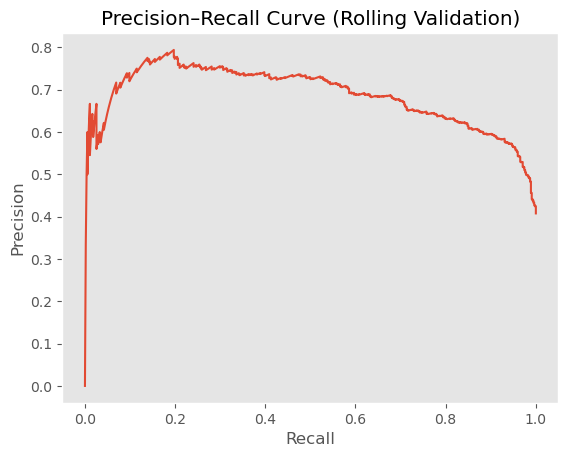

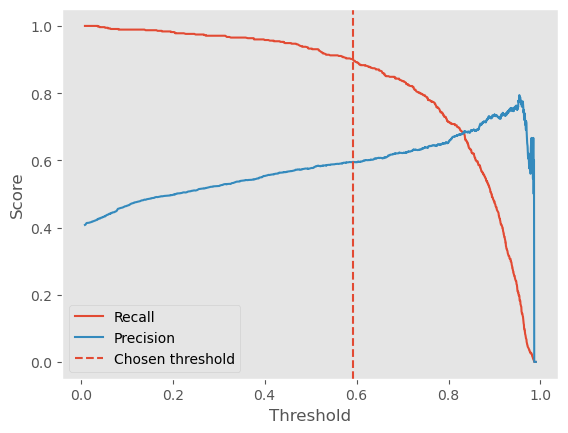

{'threshold': np.float32(0.5924452), 'precision': 0.5958986731001207, 'recall': 0.9014598540145985}


In [39]:
best_params_reduced_prefixed = {f"model__{k}": v for k, v in best_trial_reduced.params.items()}

best_threshold_info, threshold_results = find_best_threshold_pr_curve(
    df=train_val,
    features=features_reduced,
    target='biodiversity_anomaly_sensitive',
    pipeline=full_pipeline_xgb_reduced,
    best_params=best_params_reduced_prefixed,
    min_recall=0.9,
    plot=True
)

print(best_threshold_info)

Use best parameters for training on full training data with best threshold

In [40]:
best_params_reduced = best_trial_reduced.params
best_params_prefixed = {f"model__{k}": v for k, v in best_params_reduced.items()}
#best_threshold_reduced = best_trial_reduced.user_attrs['best_threshold_f1']
#best_threshold_recall = best_trial_reduced.user_attrs['best_threshold_recall']
threshold = best_threshold_info['threshold']

# Set these in your pipeline
full_pipeline_xgb_reduced.set_params(**best_params_prefixed)

# Fit the pipeline on full training data
X_trainval_reduced = X_trainval[features_reduced]
full_pipeline_xgb_reduced.fit(X_trainval_reduced, y_trainval)

# Predict probabilities on test set
X_test_reduced = X_test[features_reduced]
y_proba_reduced = full_pipeline_xgb_reduced.predict_proba(X_test_reduced)[:, 1]
y_pred_reduced = (y_proba_reduced > threshold).astype(int)

# Evaluate
from sklearn.metrics import f1_score, accuracy_score
print("F1 on test:", f1_score(y_test, y_pred_reduced, average='macro'))

F1 on test: 0.8551579261859635


Nice! F1 value of 0.85 on test set

Evaluate with a confusion matrix

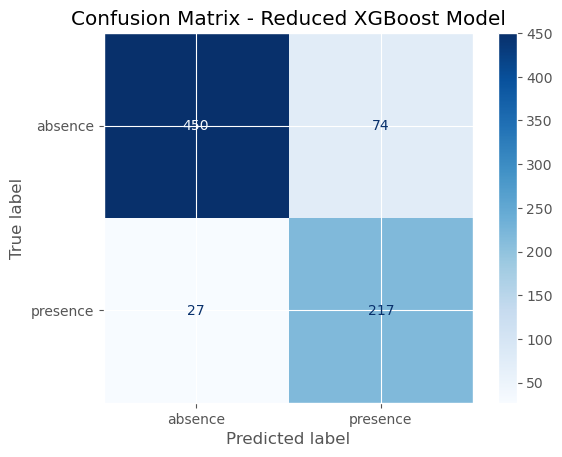

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_reduced)

# Create display
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['absence', 'presence'])  # adjust labels as needed
disp.plot(cmap='Blues')  # you can change color map

# Optionally add titles
import matplotlib.pyplot as plt
plt.title("Confusion Matrix - Reduced XGBoost Model")
plt.show()

---
Train production model using all data (train and test together) with best params

In [42]:
# clone the pipeline as a production model
pipeline_production = clone(full_pipeline_xgb_reduced)
pipeline_production.set_params(**best_params_prefixed)

# Fit the production pipeline on full data
X_full_reduced = df[features_reduced].copy()
y_full = df['biodiversity_anomaly_sensitive']
pipeline_production.fit(X_full_reduced, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [43]:
# sanity check
y_proba = pipeline_production.predict_proba(X_full_reduced)[:,1]
threshold = best_threshold_info['threshold']
y_pred = (y_proba > threshold).astype(int)

print(f1_score(y_full, y_pred))

0.9007291082445317


save evaluation model and production model

In [44]:
import joblib

joblib.dump({
    "model": full_pipeline_xgb_reduced,
    "threshold": best_threshold_info['threshold'],
    "features": features_reduced
}, "../models/evaluation_model_classifier.pkl")

joblib.dump({
    "model": pipeline_production,
    "threshold": best_threshold_info['threshold'],
    "features": features_reduced
}, "../models/production_model_classifier.pkl")

['../models/production_model_classifier.pkl']